In [1]:
# Present original catalog and ETAS simulation from a continuation output folder
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eq_mag_prediction.data.catalog_methods as catalog_methods
%matplotlib inline


2026-03-10 12:23:16.208948: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 12:23:16.259942: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 12:23:16.528802: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-10 12:23:16.529152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-10 12:23:16.561053: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [7]:
# Path to an ETAS simulation folder (from "Saving reproduction files" in pipeline)
# Example: outputs/continuation/model_<hash>_<inv_hash>/
# Run from etas_edits repo root, or set simulation_dir to an absolute path.
repo_root = pathlib.Path.cwd() if (pathlib.Path.cwd() / "outputs" / "continuation").exists() else pathlib.Path.cwd().parent
simulation_dir = repo_root / "outputs" / "continuation" / "model_11a8e72f2a4e7c5f25e2f3db852ca526e50dbeed_abdec1f00a012f14"
# simulation_dir = pathlib.Path("/home/neriberman/REPOS/etas_edits/outputs/continuation/model_7166e48cabdd3b789e48a277e632d6cc39566d90_fd5244d9918d74eb")
path_original = simulation_dir / "original_catalog.csv"
path_simulated = simulation_dir / "simulated_catalog.csv"
assert path_original.exists(), f"Original catalog not found: {path_original}"
assert path_simulated.exists(), f"Simulated catalog not found: {path_simulated}"
print(f"Original: {path_original}")
print(f"Simulated: {path_simulated}")


Original: /home/neriberman/REPOS/etas_edits/outputs/continuation/model_11a8e72f2a4e7c5f25e2f3db852ca526e50dbeed_abdec1f00a012f14/original_catalog.csv
Simulated: /home/neriberman/REPOS/etas_edits/outputs/continuation/model_11a8e72f2a4e7c5f25e2f3db852ca526e50dbeed_abdec1f00a012f14/simulated_catalog.csv


In [8]:
catalog = pd.read_csv(path_original)
catalog["time"] = pd.to_datetime(catalog["time"])
simulated = pd.read_csv(path_simulated)
simulated["time"] = pd.to_datetime(simulated["time"])
# If multiple catalog_id (many simulations), keep first run or aggregate as needed
if "catalog_id" in simulated.columns:
    simulated_one = simulated[simulated["catalog_id"] == simulated["catalog_id"].iloc[0]].copy()
else:
    simulated_one = simulated.copy()
print(f"Original catalog: {len(catalog)} events")
print(f"Simulated catalog: {len(simulated_one)} events")
catalog.head(1000)


Original catalog: 266662 events
Simulated catalog: 0 events


,id,latitude,longitude,time,magnitude
0,1,33.25517,-115.96750,1981-01-01 04:13:55,2.26
1,2,34.18600,-117.29733,1981-01-01 05:20:14,2.37
2,3,34.18433,-117.29600,1981-01-01 05:39:56,1.60
3,4,34.00633,-117.16200,1981-01-01 08:23:18,1.88
4,5,34.09367,-117.30517,1981-01-01 10:57:34,1.40
...,...,...,...,...,...
995,996,33.17433,-115.64267,1981-04-28 12:51:29,1.83
996,997,33.21633,-115.56250,1981-04-28 14:00:02,2.41
997,998,33.04067,-115.69450,1981-04-28 14:13:57,1.70
998,999,33.06417,-115.66983,1981-04-28 14:31:37,2.08


In [ ]:
pd.read_csv(path_simulated)


,id,latitude,longitude,magnitude,time


In [14]:
simulated


,id,latitude,longitude,magnitude,time


In [10]:
simulated_one["magnitude"]


Series([], Name: magnitude, dtype: object)

ValueError: s must be a scalar, or float array-like with the same size as x and y

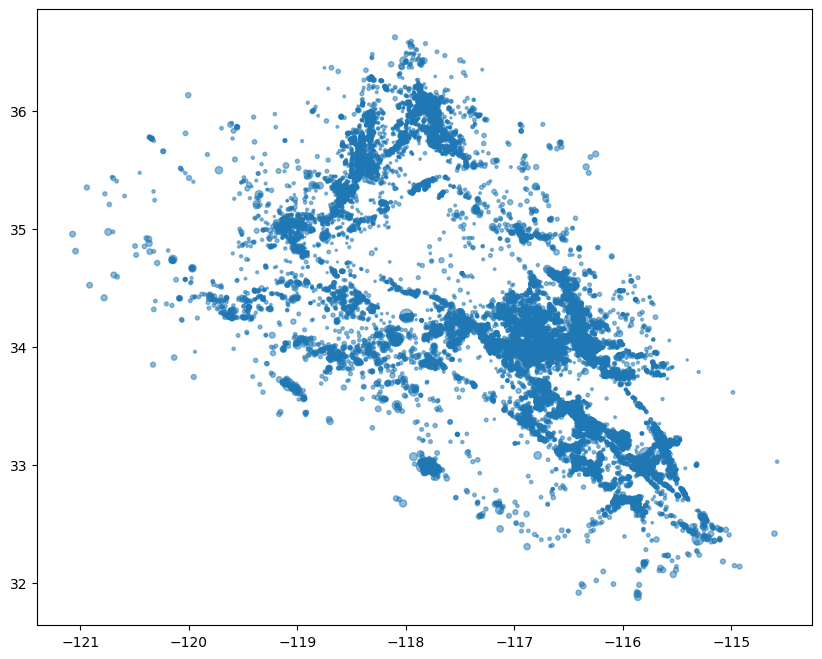

In [11]:
# Spatial view: original catalog (blue) and ETAS simulation (red)
f_spatial, ax_spatial = plt.subplots(figsize=(10, 8))
n_orig = min(50000, len(catalog))
ax_spatial.scatter(
    catalog.head(n_orig)["longitude"], catalog.head(n_orig)["latitude"],
    s=2.2 ** catalog.head(n_orig)["magnitude"], alpha=0.5, c="C0", label="Original catalog"
)
ax_spatial.scatter(
    simulated_one["longitude"], simulated_one["latitude"],
    s=2.2 ** simulated_one["magnitude"], alpha=0.6, c="C1", label="ETAS simulation"
)
ax_spatial.set_xlabel("Longitude")
ax_spatial.set_ylabel("Latitude")
ax_spatial.legend()
ax_spatial.set_aspect("equal")
plt.tight_layout()
plt.show()


In [ ]:
# Time series: original catalog (blue) and ETAS simulation (red)
import matplotlib.dates as mdates
f_time_series, ax_time_series = plt.subplots(figsize=(10, 6))
ax_time_series.scatter(
    catalog["time"], catalog["magnitude"],
    s=4, alpha=0.4, c="C0", label="Original catalog"
)
ax_time_series.scatter(
    simulated_one["time"], simulated_one["magnitude"],
    s=4, alpha=0.6, c="C1", label="ETAS simulation"
)
ax_time_series.set_xlabel("Time")
ax_time_series.set_ylabel("Magnitude")
ax_time_series.legend()
ax_time_series.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Optional: plot using catalog_tools (map with basemap)
# f_map, ax_map = plt.subplots(subplot_kw=dict(projection=...))
# catalog.catalog_tools.plot_map(ax=ax_map)
# simulated_one.catalog_tools.plot_map(ax=ax_map, c='red')


In [ ]:
# Time range of original and simulated
print("Original:", catalog["time"].min(), "to", catalog["time"].max())
print("Simulated:", simulated_one["time"].min(), "to", simulated_one["time"].max())


4629334    2023-03-31 00:41:47.910000
4629337    2023-03-31 00:46:21.359999
4629338    2023-03-31 00:46:55.089999
4629352    2023-03-31 01:23:31.130000
4629357    2023-03-31 01:41:39.690000
4629362    2023-03-31 01:57:19.349999
4629365    2023-03-31 02:00:20.130000
4629370    2023-03-31 02:06:32.150000
4629409    2023-03-31 03:35:47.779999
4629410    2023-03-31 03:39:39.779999
4629429    2023-03-31 04:42:08.420000
4629431    2023-03-31 04:45:25.980000
4629435    2023-03-31 05:00:14.589999
4629443    2023-03-31 05:28:14.029999
4629453    2023-03-31 06:22:24.890000
4629464    2023-03-31 07:01:01.160000
4629483    2023-03-31 07:48:40.329999
4629488    2023-03-31 07:59:06.220000
4629558    2023-03-31 10:41:04.730000
4629563    2023-03-31 10:47:14.430000
4629565    2023-03-31 10:48:56.279999
4629566    2023-03-31 10:49:00.089999
4629568    2023-03-31 10:59:55.769999
4629572    2023-03-31 11:11:59.640000
4629574    2023-03-31 11:14:09.670000
4629604    2023-03-31 12:13:36.190000
4629615    2

In [ ]:
# Summary stats
print("Original  magnitude range:", catalog["magnitude"].min(), "-", catalog["magnitude"].max())
print("Simulated magnitude range:", simulated_one["magnitude"].min(), "-", simulated_one["magnitude"].max())


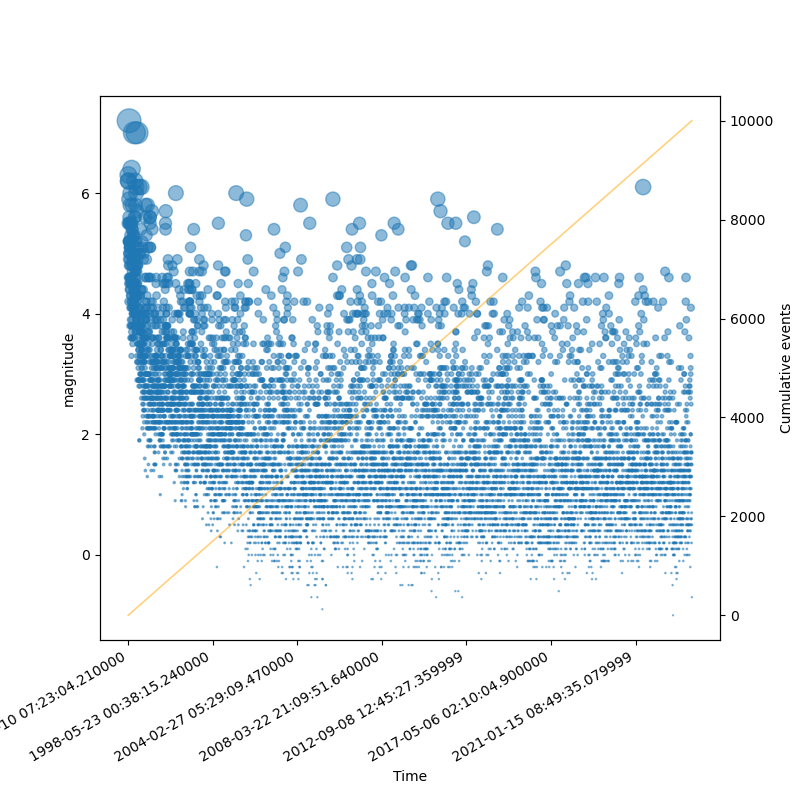

In [ ]:
# Time series with catalog_tools (stem plot) - original only
import matplotlib.ticker as mticker
f_ts2, ax_ts2 = plt.subplots(figsize=(8, 6))
catalog.catalog_tools.plot_time_series("magnitude", completeness=np.nan, ax=ax_ts2)
ax_ts2.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
plt.tight_layout()
plt.show().autofmt_xdate()


In [ ]:
# Config used for this continuation (if available)
config_path = simulation_dir / "continuation_config.json"
if config_path.exists():
    import json
    with open(config_path) as f:
        cont_config = json.load(f)
    print(json.dumps(cont_config, indent=2))


In [ ]:
# Simulated catalog (full table preview)
simulated_one


,id,latitude,longitude,magnitude,time
0,3305,34.267862,-119.624258,3.9,2007-01-14 20:20:59.969159000
1,3306,36.613851,-119.854002,3.8,2007-01-20 12:43:39.053286000
2,3307,41.066503,-122.454900,3.7,2007-01-21 04:35:42.369799000
3,3308,37.600557,-117.555641,3.8,2007-02-18 23:51:57.030534000
4,3309,34.395704,-117.372478,3.6,2007-03-09 12:36:05.031923000
...,...,...,...,...,...
888,4196,41.030147,-124.597739,4.7,2016-10-18 01:32:18.238085741
889,4197,41.201606,-124.598553,3.6,2016-12-01 09:38:31.935607243
890,4198,41.030653,-124.585439,3.9,2016-10-18 05:40:23.333551304
891,4199,41.037563,-124.597247,3.6,2016-10-26 07:09:30.687064561


In [ ]:
# (Spatial and time-series plots with both catalogs are in cells above.)


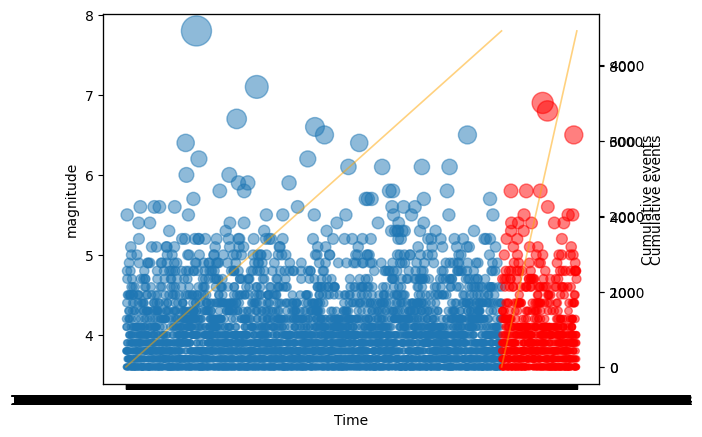

In [ ]:
# Simulated catalog time series via catalog_tools (stem)
f_ts_sim, ax_ts_sim = plt.subplots(figsize=(8, 6))
simulated_one.catalog_tools.plot_time_series("magnitude", completeness=np.nan, ax=ax_ts_sim)
plt.tight_layout()
plt.show()


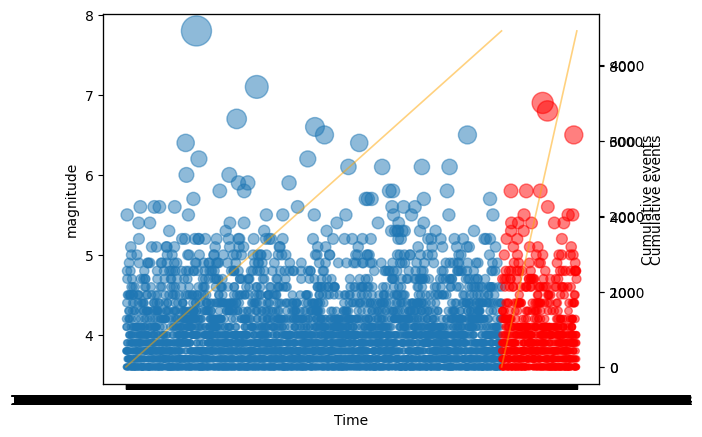

In [ ]:
# Done. Change simulation_dir in cell 1 to view another ETAS continuation folder.


In [ ]:
catalog.sort_values("time")


,id,latitude,longitude,time,magnitude
0,1065,37.725523,-118.455907,1971-01-02 20:23:51.985259000,3.8
1,1066,37.613990,-117.181949,1971-01-05 10:06:37.827212000,4.2
2041,5758,36.649046,-114.791831,1971-01-06 01:20:23.580918000,4.2
2434,6509,42.111072,-118.701570,1971-02-25 11:24:47.962124800,3.8
3255,8113,32.228058,-113.514014,1971-02-28 02:21:35.531699799,4.4
...,...,...,...,...,...
3658,8852,32.160837,-117.655027,2020-12-15 06:13:27.342446400,4.1
3463,8482,32.110714,-117.467247,2020-12-16 16:10:08.818516800,4.1
3657,8851,32.110708,-117.450863,2020-12-17 13:09:32.010561600,3.8
3961,9419,38.025073,-120.030247,2020-12-23 01:28:22.989432800,4.2


,id,latitude,longitude,time,magnitude
0,1065,37.725523,-118.455907,1971-01-02 20:23:51.985259000,3.8
1,1066,37.613990,-117.181949,1971-01-05 10:06:37.827212000,4.2
2041,5758,36.649046,-114.791831,1971-01-06 01:20:23.580918000,4.2
2434,6509,42.111072,-118.701570,1971-02-25 11:24:47.962124800,3.8
3255,8113,32.228058,-113.514014,1971-02-28 02:21:35.531699799,4.4
...,...,...,...,...,...
3658,8852,32.160837,-117.655027,2020-12-15 06:13:27.342446400,4.1
3463,8482,32.110714,-117.467247,2020-12-16 16:10:08.818516800,4.1
3657,8851,32.110708,-117.450863,2020-12-17 13:09:32.010561600,3.8
3961,9419,38.025073,-120.030247,2020-12-23 01:28:22.989432800,4.2


In [ ]:
simulated_one.sort_values("time")


,id,latitude,longitude,magnitude,time
317,3625,35.633080,-115.548568,3.9,2007-01-01 03:24:39.911036195
295,3603,41.264498,-119.803934,4.6,2007-01-02 05:24:09.436598552
326,3634,35.758570,-115.392281,4.7,2007-01-02 22:43:47.235264773
0,3305,34.267862,-119.624258,3.9,2007-01-14 20:20:59.969159000
135,3440,34.246966,-119.621515,3.7,2007-01-14 20:22:19.601386122
...,...,...,...,...,...
130,3435,42.049849,-124.045989,3.6,2016-12-07 20:03:00.795076000
131,3436,42.966978,-122.255478,3.9,2016-12-13 00:02:36.101591000
596,3904,35.853229,-114.827405,3.7,2016-12-20 03:13:05.843029202
132,3437,32.553924,-113.875355,3.9,2016-12-24 20:01:29.901778000
